
# Computer Vision Practicals
## Practical 1 & Practical 2 (Complete)

**Practical 1:** CNN from Scratch (CIFAR-10)  
**Practical 2:** Transfer Learning (Cats vs Dogs – MobileNetV2)

This notebook is **beginner-friendly**, **step-by-step**, and **exam-ready**.



# 🧪 PRACTICAL 1  
## Image Classification using CNN (CIFAR-10)


## Step 1: Import Required Libraries

In [2]:

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt


## Step 2: Load and Preprocess Dataset

In [2]:

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize images
x_train = x_train / 255.0
x_test  = x_test / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)


Training shape: (50000, 32, 32, 3)
Testing shape: (10000, 32, 32, 3)


## Step 3: Class Names

In [3]:

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']


## Step 4: Visualize Sample Images

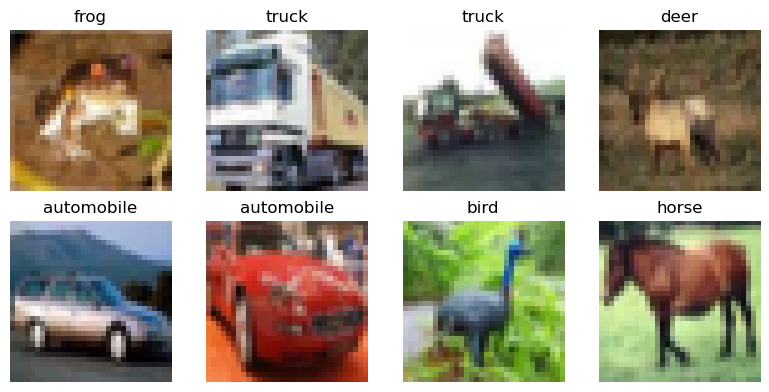

In [4]:

plt.figure(figsize=(8,4))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[np.argmax(y_train[i])])
    plt.axis('off')
plt.tight_layout()
plt.show()


## Step 5: Build CNN Model

In [5]:
model_cnn = models.Sequential([

    # Block 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # Classifier
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])


C:\Users\vicky\Anaconda 2\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Step 6: Compile Model

In [6]:
model_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Step 7: Train Model

In [7]:
history_cnn = model_cnn.fit(
    x_train, y_train,
    epochs=30,          # increased
    batch_size=64,      # better batch size
    validation_data=(x_test, y_test)
)

Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 85s 104ms/step - accuracy: 0.5088 - loss: 1.4493 - val_accuracy: 0.5627 - val_loss: 1.2315
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 100s 128ms/step - accuracy: 0.6564 - loss: 0.9765 - val_accuracy: 0.6237 - val_loss: 1.0880
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 78s 100ms/step - accuracy: 0.7023 - loss: 0.8460 - val_accuracy: 0.6653 - val_loss: 0.9968
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 75s 96ms/step - accuracy: 0.7303 - loss: 0.7655 - val_accuracy: 0.7267 - val_loss: 0.7785
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 77s 98ms/step - accuracy: 0.7556 - loss: 0.7016 - val_accuracy: 0.7616 - val_loss: 0.6915
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 107ms/step - accuracy: 0.7763 - loss: 0.6394 - val_accuracy: 0.7715 - val_loss: 0.6515
Epoch 7/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 92s 117ms/step - accuracy: 0.7865 - loss: 0.6042 - val_accuracy: 0.7760 - val_loss: 0.6466
Epoch 8/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 86s 110ms/step - accuracy: 0.8052 - loss: 0.

## Step 8: Evaluate Model

In [8]:

loss, acc = model_cnn.evaluate(x_test, y_test)
print(f"Test Accuracy: {acc*100:.2f}%")


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8315 - loss: 0.5775
Test Accuracy: 83.15%


## Step 9: Accuracy & Loss Graphs

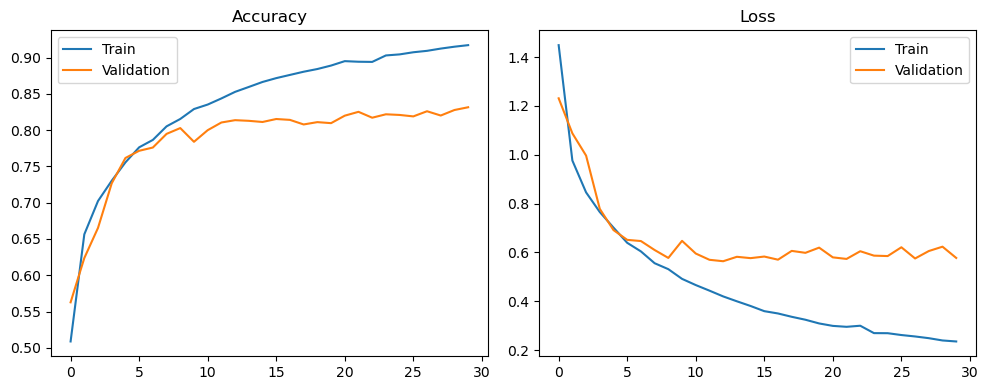

In [9]:

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history_cnn.history['accuracy'], label='Train')
plt.plot(history_cnn.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_cnn.history['loss'], label='Train')
plt.plot(history_cnn.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()



# 🧪 PRACTICAL 2  
## Transfer Learning using MobileNetV2 (Cats vs Dogs)


## Step 1: Import Libraries

In [8]:

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
import os


## Step 2: Dataset Paths

In [9]:

BASE_DIR = r"C:\Users\vicky\Desktop\CV\dataset"

TRAIN_DIR = os.path.join(BASE_DIR, "training_set")
TEST_DIR  = os.path.join(BASE_DIR, "test_set")

print(os.path.exists(TRAIN_DIR), os.path.exists(TEST_DIR))


True True


## Step 3: Image Parameters

In [10]:

IMG_SIZE = (160, 160)
BATCH_SIZE = 32


## Step 4: Data Generators

In [11]:

train_gen = ImageDataGenerator(rescale=1./255, horizontal_flip=True)
test_gen = ImageDataGenerator(rescale=1./255)


## Step 5: Load Dataset

In [12]:

train_data = train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_data = test_gen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)


Found 8005 images belonging to 2 classes.
Found 2023 images belonging to 2 classes.


## Step 6: Load Pre-trained Model

In [13]:

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(160,160,3)
)

base_model.trainable = False


## Step 7: Build Transfer Learning Model

In [14]:

model_tl = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])


## Step 8: Compile Model

In [15]:

model_tl.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_tl.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160 (Functional)    │ (None, 5, 5, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Step 9: Train Model

In [16]:

history_tl = model_tl.fit(
    train_data,
    epochs=5,
    validation_data=test_data
)


Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 162s 632ms/step - accuracy: 0.9587 - loss: 0.1005 - val_accuracy: 0.9763 - val_loss: 0.0598
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 69s 273ms/step - accuracy: 0.9796 - loss: 0.0568 - val_accuracy: 0.9763 - val_loss: 0.0648
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 69s 274ms/step - accuracy: 0.9793 - loss: 0.0508 - val_accuracy: 0.9743 - val_loss: 0.0683
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 69s 276ms/step - accuracy: 0.9888 - loss: 0.0347 - val_accuracy: 0.9778 - val_loss: 0.0673
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 71s 285ms/step - accuracy: 0.9904 - loss: 0.0253 - val_accuracy: 0.9753 - val_loss: 0.0715


## Step 10: Evaluate Model

In [17]:

loss, acc = model_tl.evaluate(test_data)
print(f"Test Accuracy: {acc*100:.2f}%")


64/64 ━━━━━━━━━━━━━━━━━━━━ 14s 219ms/step - accuracy: 0.9753 - loss: 0.0715
Test Accuracy: 97.53%
